# DDoS Detection Notebook

Training a classifier to distinguish benign traffic from DDoS attacks using the CICIDS2017

**Steps**
1. Load the CSV
2. Check for data issues (inf, nan, etc.)
3. Preprocess and scale
4. Train a Random Forest
5. Evaluate (focusing on F1/recall since this is security)
6. Save everything for the API

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

# nicer output
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

# figure out where things are
PROJECT_ROOT = Path.cwd()
DATA_FILE = PROJECT_ROOT / "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv"
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Data file exists: {DATA_FILE.exists()}")

Project root: D:\ML Project\anomaly_detection-main
Data file exists: True


## 1. Load the data

In [6]:
# load it up
df_raw = pd.read_csv(DATA_FILE)

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
print(f"\nMemory: {df_raw.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\nFirst few rows:")
df_raw.head(3)

DATASET OVERVIEW
Shape: 225,745 rows x 79 columns

Memory: 145.94 MB

First few rows:


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,4.000000e+06,666666.66670,3.0,0.0,3,3,3,3.0,0.0,3,3,0,0.0,0.0,0,0,0,0,0,0,40,0,666666.666700,0.000000,6,6,6.0,0.0,0.0,0,0,0,0,1,0,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,33,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,1.100917e+05,18348.62385,109.0,0.0,109,109,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,9174.311927,9174.311927,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,1,9.0,6.0,6.0,20,0,0,0,0,0,0,1,6,1,6,29,256,0,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,2.307692e+05,38461.53846,52.0,0.0,52,52,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,19230.769230,19230.769230,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,1,9.0,6.0,6.0,20,0,0,0,0,0,0,1,6,1,6,29,256,0,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [7]:
# the column names have trailing spaces - fix that
df = df_raw.copy()
df.columns = df.columns.str.strip()

print("Columns after stripping whitespace:")
print(list(df.columns))

Columns after stripping whitespace:
['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count


LABEL DISTRIBUTION

Class counts:
  DDoS: 128,027 (56.71%)
  BENIGN: 97,718 (43.29%)

Imbalance ratio: 1.31:1


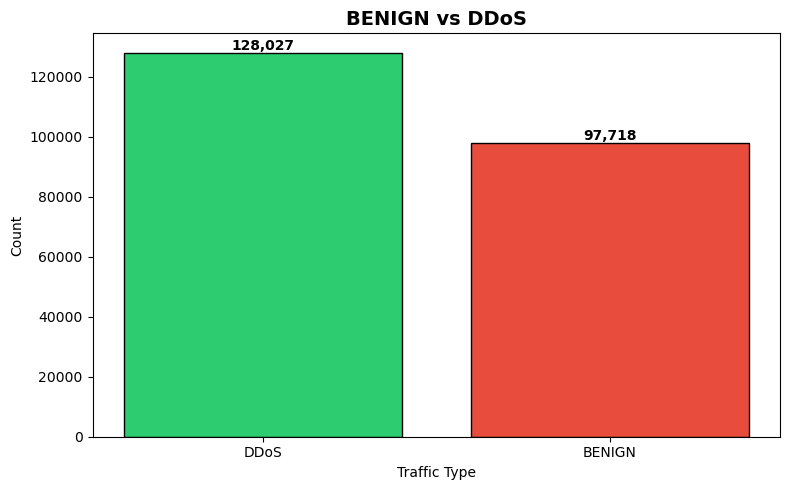

In [8]:
# what's the split between benign and attack?
print("\nLABEL DISTRIBUTION")
print("=" * 60)

label_counts = df["Label"].value_counts()
print("\nClass counts:")
for label, count in label_counts.items():
    pct = count / len(df) * 100
    print(f"  {label}: {count:,} ({pct:.2f}%)")

imbalance_ratio = label_counts.max() / label_counts.min()
print(f"\nImbalance ratio: {imbalance_ratio:.2f}:1")

# quick bar chart
plt.figure(figsize=(8, 5))
colors = ["#2ecc71", "#e74c3c"]
bars = plt.bar(label_counts.index, label_counts.values, color=colors, edgecolor="black")
plt.title("BENIGN vs DDoS", fontsize=14, fontweight="bold")
plt.xlabel("Traffic Type")
plt.ylabel("Count")

for bar, count in zip(bars, label_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1000,
        f"{count:,}",
        ha="center",
        fontweight="bold",
    )

plt.tight_layout()
plt.show()

## 2. Check for data quality issues

In [9]:
# look for inf, nan, duplicates
print("\nDATA QUALITY CHECK")
print("=" * 60)

numeric_df = df.select_dtypes(include=[np.number])
inf_count = np.isinf(numeric_df.values).sum()
print(f"\n1. Infinity values: {inf_count:,}")

# which columns have inf?
inf_columns = []
for col in numeric_df.columns:
    inf_in_col = np.isinf(numeric_df[col]).sum()
    if inf_in_col > 0:
        inf_columns.append((col, inf_in_col))

if inf_columns:
    print("   Columns with inf:")
    for col, count in inf_columns:
        print(f"     - {col}: {count:,}")

nan_count = df.isna().sum().sum()
print(f"\n2. NaN values: {nan_count:,}")

if nan_count > 0:
    nan_cols = df.columns[df.isna().any()].tolist()
    print(f"   Columns with NaN: {nan_cols}")

dup_count = df.duplicated().sum()
print(f"\n3. Duplicate rows: {dup_count:,}")

print(f"\n4. Column types:")
print(f"   Numeric: {len(df.select_dtypes(include=[np.number]).columns)}")
print(f"   Object: {len(df.select_dtypes(include=['object']).columns)}")


DATA QUALITY CHECK

1. Infinity values: 64
   Columns with inf:
     - Flow Bytes/s: 30
     - Flow Packets/s: 34

2. NaN values: 4
   Columns with NaN: ['Flow Bytes/s']

3. Duplicate rows: 2,633

4. Column types:
   Numeric: 78
   Object: 1


In [10]:
# these columns would let the model cheat - need to drop them
identifier_columns = ["Flow ID", "Source IP", "Destination IP", "Timestamp"]
existing_identifiers = [col for col in identifier_columns if col in df.columns]

print("IDENTIFIER COLUMNS (dropping these):")
for col in existing_identifiers:
    if col in df.columns:
        print(f"  - {col}: {df[col].nunique()} unique values")
        if col != "Timestamp":
            print(f"    Example: {df[col].iloc[0]}")

IDENTIFIER COLUMNS (dropping these):


## 3. Preprocess the data

Steps:
1. Strip column name whitespace
2. Keep only BENIGN and DDoS labels
3. Drop identifier columns (IPs, Flow ID, Timestamp)
4. Replace inf with max finite value
5. Drop NaN rows
6. Encode labels (BENIGN=0, DDoS=1)
7. Scale features with StandardScaler

In [11]:
# bring in our preprocessing module
import sys

sys.path.insert(0, str(PROJECT_ROOT))

from src.preprocessing import (
    DataPreprocessor,
    get_class_distribution,
    check_data_quality,
)

# run the quality check function
print("Quality before preprocessing:")
quality_before = check_data_quality(df_raw)
for key, value in quality_before.items():
    print(f"  {key}: {value}")

Quality before preprocessing:
  infinity_values: 64
  nan_values: 4
  duplicate_rows: 2633
  columns_with_infinity: ['Flow Bytes/s', ' Flow Packets/s']
  total_rows: 225745
  total_columns: 79


In [12]:
# run the full preprocessing pipeline
preprocessor = DataPreprocessor()
X_scaled, y = preprocessor.fit_transform(df_raw)

print("\n" + "=" * 60)
print("PREPROCESSING DONE")
print("=" * 60)
print(f"X shape: {X_scaled.shape}")
print(f"y shape: {y.shape}")
print(f"Features: {len(preprocessor.feature_names)}")

Running preprocessing...
1. Cleaned column names. Shape: (225745, 79)
2. Filtered to valid labels. Shape: (225745, 79)
3. Dropped identifier columns. Shape: (225745, 79)
  Dropped leaky features: ['Destination Port']
4. Dropped leaky features. Shape: (225745, 78)
5. Added engineered features. Shape: (225745, 83)
6. Replaced infinity values. Shape: (225745, 83)
Dropped 4 rows with NaN values (0.00%)
7. Dropped NaN rows. Shape: (225741, 83)
8. Encoded labels. Shape: (225741, 83)
9. Extracted 82 features
10. Scaled features. Final shape: (225741, 82)

PREPROCESSING DONE
X shape: (225741, 82)
y shape: (225741,)
Features: 82


In [13]:
# double check class distribution after processing
print("\nClass distribution after preprocessing:")
distribution = get_class_distribution(y)
for label, stats in distribution.items():
    if isinstance(stats, dict):
        print(f"  {label}: {stats['count']:,} samples ({stats['percentage']}%)")
    else:
        print(f"  {label}: {stats}")


Class distribution after preprocessing:
  BENIGN: 97,714 samples (43.29%)
  DDoS: 128,027 samples (56.71%)
  imbalance_ratio: 1.31


In [14]:
# list out the features
print(f"\nFeatures ({len(preprocessor.feature_names)} total):")
for i, name in enumerate(preprocessor.feature_names, 1):
    print(f"  {i:2}. {name}")


Features (82 total):
   1. Flow Duration
   2. Total Fwd Packets
   3. Total Backward Packets
   4. Total Length of Fwd Packets
   5. Total Length of Bwd Packets
   6. Fwd Packet Length Max
   7. Fwd Packet Length Min
   8. Fwd Packet Length Mean
   9. Fwd Packet Length Std
  10. Bwd Packet Length Max
  11. Bwd Packet Length Min
  12. Bwd Packet Length Mean
  13. Bwd Packet Length Std
  14. Flow Bytes/s
  15. Flow Packets/s
  16. Flow IAT Mean
  17. Flow IAT Std
  18. Flow IAT Max
  19. Flow IAT Min
  20. Fwd IAT Total
  21. Fwd IAT Mean
  22. Fwd IAT Std
  23. Fwd IAT Max
  24. Fwd IAT Min
  25. Bwd IAT Total
  26. Bwd IAT Mean
  27. Bwd IAT Std
  28. Bwd IAT Max
  29. Bwd IAT Min
  30. Fwd PSH Flags
  31. Bwd PSH Flags
  32. Fwd URG Flags
  33. Bwd URG Flags
  34. Fwd Header Length
  35. Bwd Header Length
  36. Fwd Packets/s
  37. Bwd Packets/s
  38. Min Packet Length
  39. Max Packet Length
  40. Packet Length Mean
  41. Packet Length Std
  42. Packet Length Variance
  43. FIN Flag

## 4. Train the model

Using Random Forest here because:
- Works great on tabular data
- Gives us feature importance out of the box
- Handles outliers and nonlinear stuff reasonably
- Has class_weight to deal with imbalance

In [15]:
from src.model import DDoSDetector, print_evaluation_report

# train a random forest
detector = DDoSDetector(model_type="random_forest")

print("Training...\n")
results = detector.train(
    X=X_scaled, y=y, feature_names=preprocessor.feature_names, test_size=0.2
)

Training...

Class distribution - BENIGN: 97714, DDoS: 128027
Imbalance ratio: 0.76

Training set: 180592 samples
Test set: 45149 samples

Training random_forest...


In [16]:
# how'd we do?
print_evaluation_report(results)


EVALUATION RESULTS

-- Security-Focused Metrics --
  F1-Score (DDoS):     0.9998
  Recall (DDoS):       0.9997  <- how many attacks we caught
  Precision (DDoS):    0.9999  <- how often our alerts are real

-- Overall Numbers --
  Accuracy:            0.9998
  ROC-AUC:             1.0000
  F1-Score (BENIGN):   0.9997

-- Confusion Matrix --
                    Predicted
                 BENIGN   DDoS
  Actual BENIGN    19541       2
  Actual DDoS          8   25598

-- Error Breakdown --
  True Negatives  (Benign -> Benign): 19541
  False Positives (Benign -> Attack): 2  - annoying but not dangerous
  False Negatives (Attack -> Benign): 8  - these are the scary ones
  True Positives  (Attack -> Attack): 25598

CLASSIFICATION REPORT
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     19543
        DDoS       1.00      1.00      1.00     25606

    accuracy                           1.00     45149
   macro avg       1.00      1.00      

## 5. Visualizations

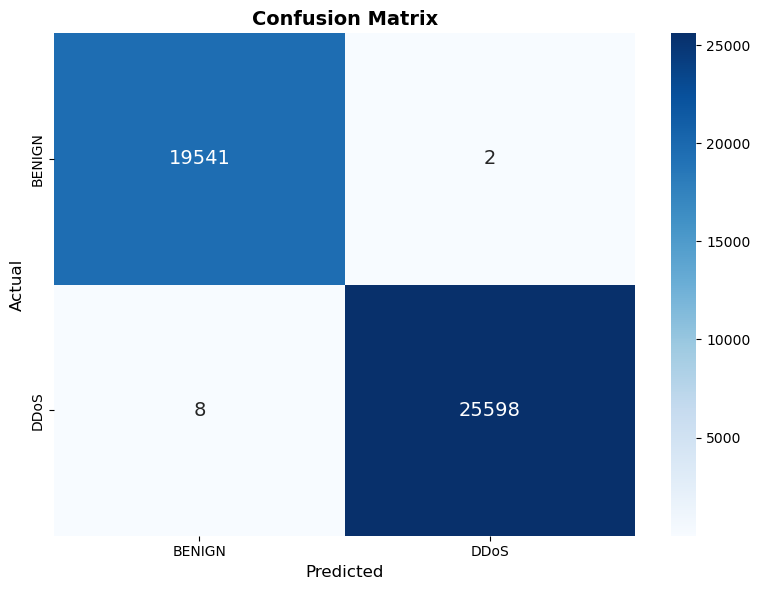

In [17]:
# confusion matrix heatmap
cm = results["confusion_matrix"]

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["BENIGN", "DDoS"],
    yticklabels=["BENIGN", "DDoS"],
    annot_kws={"size": 14},
)
plt.title("Confusion Matrix", fontsize=14, fontweight="bold")
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("Actual", fontsize=12)
plt.tight_layout()
plt.show()

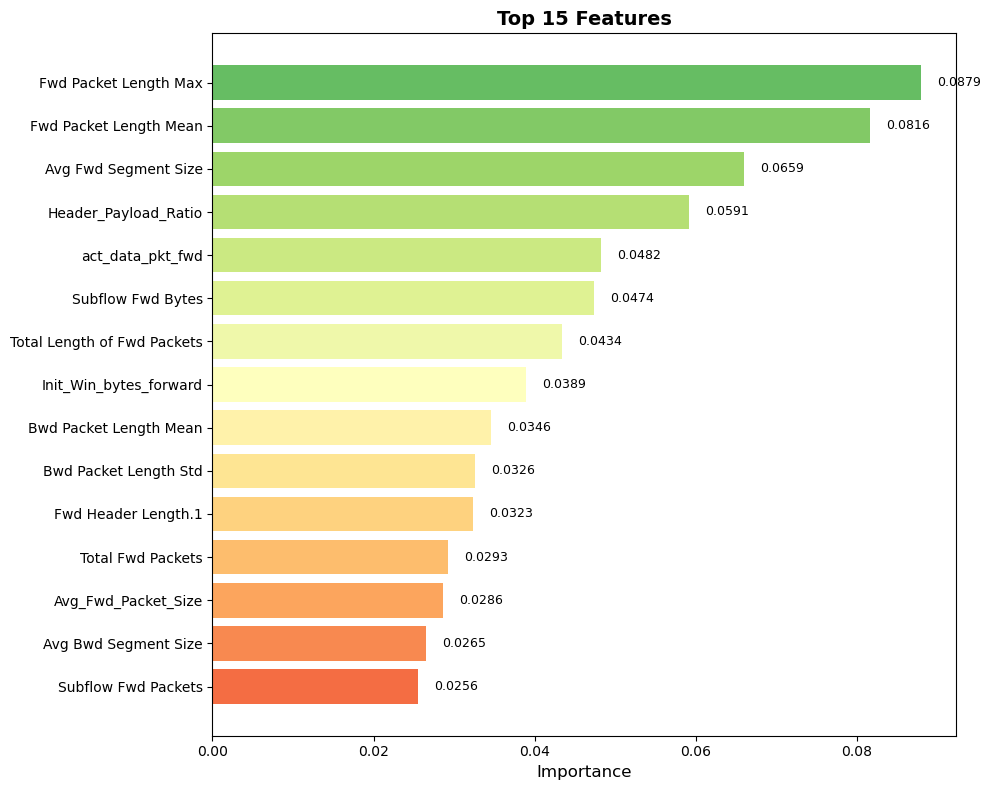

In [18]:
# which features matter most?
if results["feature_importances"] is not None:
    top_features = results["feature_importances"].head(15)

    plt.figure(figsize=(10, 8))
    colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(top_features)))[::-1]
    bars = plt.barh(range(len(top_features)), top_features["importance"], color=colors)
    plt.yticks(range(len(top_features)), top_features["feature"])
    plt.xlabel("Importance", fontsize=12)
    plt.title("Top 15 Features", fontsize=14, fontweight="bold")
    plt.gca().invert_yaxis()

    for bar, imp in zip(bars, top_features["importance"]):
        plt.text(
            imp + 0.002,
            bar.get_y() + bar.get_height() / 2,
            f"{imp:.4f}",
            va="center",
            fontsize=9,
        )

    plt.tight_layout()
    plt.show()

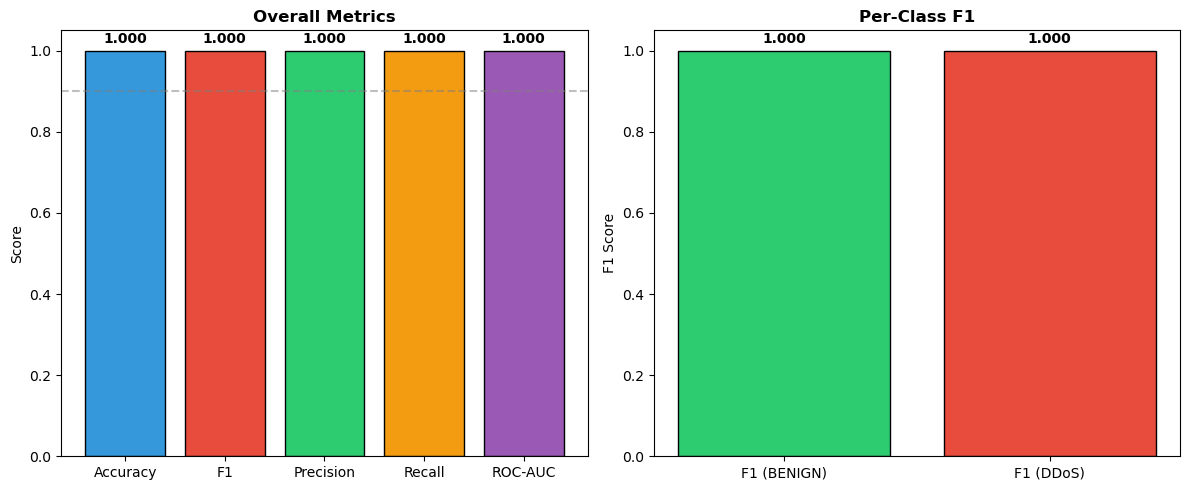

In [19]:
# metrics side by side
metrics = results["metrics"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# overall
metric_names = ["Accuracy", "F1", "Precision", "Recall", "ROC-AUC"]
metric_values = [
    metrics["accuracy"],
    metrics["f1_score"],
    metrics["precision"],
    metrics["recall"],
    metrics["roc_auc"],
]

colors = ["#3498db", "#e74c3c", "#2ecc71", "#f39c12", "#9b59b6"]
bars = axes[0].bar(metric_names, metric_values, color=colors, edgecolor="black")
axes[0].set_ylim(0, 1.05)
axes[0].set_title("Overall Metrics", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Score")
axes[0].axhline(y=0.9, color="gray", linestyle="--", alpha=0.5)

for bar, val in zip(bars, metric_values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.02,
        f"{val:.3f}",
        ha="center",
        fontweight="bold",
    )

# per-class f1
class_f1 = ["F1 (BENIGN)", "F1 (DDoS)"]
class_values = [metrics["f1_benign"], metrics["f1_ddos"]]
class_colors = ["#2ecc71", "#e74c3c"]

bars = axes[1].bar(class_f1, class_values, color=class_colors, edgecolor="black")
axes[1].set_ylim(0, 1.05)
axes[1].set_title("Per-Class F1", fontsize=12, fontweight="bold")
axes[1].set_ylabel("F1 Score")

for bar, val in zip(bars, class_values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.02,
        f"{val:.3f}",
        ha="center",
        fontweight="bold",
    )

plt.tight_layout()
plt.show()

## 6. Cross-validation (sanity check)

In [20]:
# 5-fold CV to make sure we're not overfitting
print("Running 5-fold CV...")
cv_results = detector.cross_validate(X_scaled, y, cv=5)

print("\nCross-validation results:")
print(f"  F1:        {cv_results['f1_mean']:.4f} +/- {cv_results['f1_std']:.4f}")
print(
    f"  Precision: {cv_results['precision_mean']:.4f} +/- {cv_results['precision_std']:.4f}"
)
print(
    f"  Recall:    {cv_results['recall_mean']:.4f} +/- {cv_results['recall_std']:.4f}"
)

print("\nPer-fold F1:", [f"{s:.4f}" for s in cv_results["f1_scores"]])

Running 5-fold CV...

Cross-validation results:
  F1:        0.9998 +/- 0.0000
  Precision: 0.9999 +/- 0.0000
  Recall:    0.9997 +/- 0.0001

Per-fold F1: ['0.9998', '0.9998', '0.9998', '0.9999', '0.9998']


## 7. Save model artifacts

In [21]:
# save everything
print("Saving model...\n")

model_path = MODELS_DIR / "ddos_model.pkl"
detector.save(model_path)

scaler_path = MODELS_DIR / "scaler.pkl"
features_path = MODELS_DIR / "feature_names.pkl"
config_path = MODELS_DIR / "preprocessing_config.pkl"
preprocessor.save(scaler_path, features_path, config_path)

print("\nSaved files:")
for f in MODELS_DIR.glob("*.pkl"):
    size_kb = f.stat().st_size / 1024
    print(f"  - {f.name}: {size_kb:.1f} KB")

Saving model...

Model saved to D:\ML Project\anomaly_detection-main\models\ddos_model.pkl
Saved scaler to D:\ML Project\anomaly_detection-main\models\scaler.pkl
Saved feature names to D:\ML Project\anomaly_detection-main\models\feature_names.pkl
Saved config to D:\ML Project\anomaly_detection-main\models\preprocessing_config.pkl

Saved files:
  - ddos_model.pkl: 3071.1 KB
  - feature_names.pkl: 1.5 KB
  - preprocessing_config.pkl: 2.0 KB
  - scaler.pkl: 4.3 KB


## 8. Quick inference test

In [22]:
# make sure we can load it back
from src.model import DDoSDetector
from src.preprocessing import DataPreprocessor

loaded_model = DDoSDetector.load(MODELS_DIR / "ddos_model.pkl")
loaded_preprocessor = DataPreprocessor.load(
    MODELS_DIR / "scaler.pkl",
    MODELS_DIR / "feature_names.pkl",
    MODELS_DIR / "preprocessing_config.pkl",
)

print("Loaded successfully!")
print(f"Model type: {loaded_model.model_type}")
print(f"Training F1: {loaded_model.training_metrics['f1_score']:.4f}")

Loaded successfully!
Model type: random_forest
Training F1: 0.9998


In [23]:
# Verify model can make predictions after loading
# (Actual evaluation was done during training with 80/20 split)

sample = X_scaled[0:1]  # Just grab one sample to verify
result = loaded_model.predict_single(sample)

print("Model inference check:")
print(f"  Prediction: {result['label']}")
print(f"  Confidence: {result['confidence']:.4f}")
print(f"  P(BENIGN): {result['probability_benign']:.6f}")
print(f"  P(DDoS): {result['probability_ddos']:.6f}")
print("\n✓ Model loads and predicts correctly!")

Model inference check:
  Prediction: BENIGN
  Confidence: 1.0000
  P(BENIGN): 1.000000
  P(DDoS): 0.000000

✓ Model loads and predicts correctly!


## 10. Generate Test Data for UI

Generate random test samples with all 82 features that can be copied and pasted into the UI for testing.
The UI now accepts JSON input with all features for accurate predictions.

In [24]:
# Generate random test samples from the dataset
# These can be copied and pasted into the UI's JSON input field

import json
import random

# Use the cleaned dataframe
df_samples = df_raw.copy()
df_samples.columns = df_samples.columns.str.strip()
df_samples = df_samples[df_samples["Label"].isin(["BENIGN", "DDoS"])]

# Get indices for each class
benign_idx = df_samples[df_samples["Label"] == "BENIGN"].index.tolist()
ddos_idx = df_samples[df_samples["Label"] == "DDoS"].index.tolist()

# Random sample: 2 benign, 3 DDoS
random.shuffle(benign_idx)
random.shuffle(ddos_idx)
selected_indices = benign_idx[:2] + ddos_idx[:3]

print("=" * 80)
print("TEST SAMPLES FOR UI (Copy JSON and paste in the JSON Input field)")
print("=" * 80)

for idx, sample_idx in enumerate(selected_indices, 1):
    row = df_samples.loc[sample_idx]
    actual_label = row["Label"]

    # Create feature dict with all features the model expects
    features_dict = {}
    for feature_name in preprocessor.feature_names:
        if feature_name in row.index:
            value = row[feature_name]
            if pd.isna(value) or np.isinf(value):
                value = 0.0
            features_dict[feature_name] = float(value)
        else:
            features_dict[feature_name] = 0.0

    print(f"\n{'=' * 80}")
    print(f"SAMPLE {idx} - Expected: {actual_label}")
    print("=" * 80)
    print(json.dumps(features_dict, indent=2))

print(f"\n{'=' * 80}")
print("Copy any JSON above and paste into the UI's JSON Input field")
print("=" * 80)

TEST SAMPLES FOR UI (Copy JSON and paste in the JSON Input field)

SAMPLE 1 - Expected: BENIGN
{
  "Flow Duration": 96136.0,
  "Total Fwd Packets": 3.0,
  "Total Backward Packets": 3.0,
  "Total Length of Fwd Packets": 319.0,
  "Total Length of Bwd Packets": 4916.0,
  "Fwd Packet Length Max": 313.0,
  "Fwd Packet Length Min": 0.0,
  "Fwd Packet Length Mean": 106.3333333,
  "Fwd Packet Length Std": 179.0037244,
  "Bwd Packet Length Max": 4910.0,
  "Bwd Packet Length Min": 0.0,
  "Bwd Packet Length Mean": 1638.666667,
  "Bwd Packet Length Std": 2833.059359,
  "Flow Bytes/s": 54454.10668,
  "Flow Packets/s": 62.41158359,
  "Flow IAT Mean": 19227.2,
  "Flow IAT Std": 21198.40786,
  "Flow IAT Max": 44624.0,
  "Flow IAT Min": 50.0,
  "Fwd IAT Total": 53531.0,
  "Fwd IAT Mean": 26765.5,
  "Fwd IAT Std": 25326.44358,
  "Fwd IAT Max": 44674.0,
  "Fwd IAT Min": 8857.0,
  "Bwd IAT Total": 51512.0,
  "Bwd IAT Mean": 25756.0,
  "Bwd IAT Std": 32154.97377,
  "Bwd IAT Max": 48493.0,
  "Bwd IAT Min": 

## Summary

We've:
- Loaded and cleaned the CICIDS2017 data
- Trained a Random Forest with class balancing
- Evaluated using F1, precision, recall
- Saved everything to `models/`

To run the API:
```
uvicorn api.main:app --host 0.0.0.0 --port 8000
```